In [2]:
# SECTION 0: IMPORTS & SETUP
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Visual styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 110, 'figure.facecolor': 'white'})
%matplotlib inline

print("✅ EDA Environment Setup Complete")

✅ EDA Environment Setup Complete


In [7]:
# Load dataset
df = pd.read_csv('cleaned_travel_dataset.csv')
# Fix gender "Fe Male"
df['Gender'] = df['Gender'].replace('Fe Male', 'Female')
# 1.1 Basic Information
print("=" * 60)
print("📊 DATASET SHAPE:", df.shape)
print("=" * 60)
print("\n📋 DATA TYPES:\n", df.dtypes)
print("\n❌ MISSING VALUES:\n", df.isnull().sum())
print("\n🔍 DUPLICATES:", df.duplicated().sum())
print("\n📈 DESCRIPTIVE STATISTICS:\n", df.describe().round(2))

📊 DATASET SHAPE: (4888, 20)

📋 DATA TYPES:
 CustomerID                    int64
ProdTaken                     int64
Age                         float64
TypeofContact                object
CityTier                      int64
DurationOfPitch             float64
Occupation                   object
Gender                       object
NumberOfPersonVisiting        int64
NumberOfFollowups           float64
ProductPitched               object
PreferredPropertyStar       float64
MaritalStatus                object
NumberOfTrips               float64
Passport                      int64
PitchSatisfactionScore        int64
OwnCar                        int64
NumberOfChildrenVisiting    float64
Designation                  object
MonthlyIncome               float64
dtype: object

❌ MISSING VALUES:
 CustomerID                  0
ProdTaken                   0
Age                         0
TypeofContact               0
CityTier                    0
DurationOfPitch             0
Occupation            

IndexError: index 9 is out of bounds for axis 0 with size 9

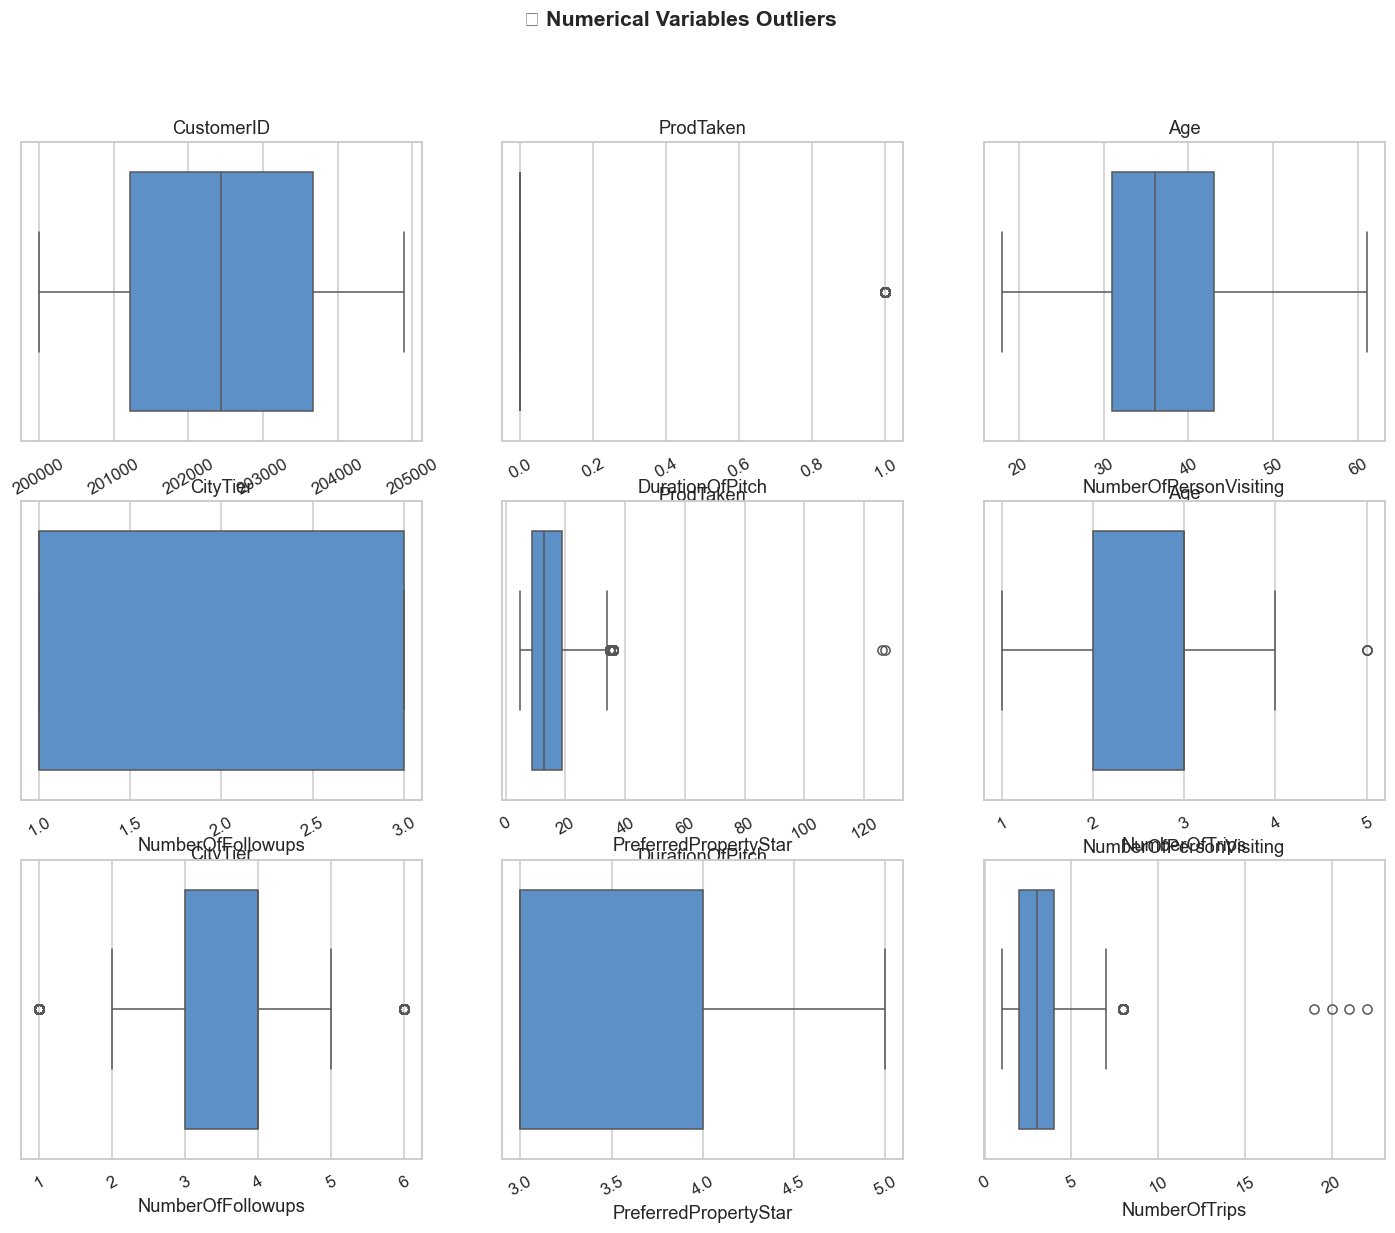

In [11]:
# outliers
num_cols = df.select_dtypes(include=np.number).columns.tolist()
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle('📈 Numerical Variables Outliers', fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x=df[col], ax=axes[i], color='#4A90D9')
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

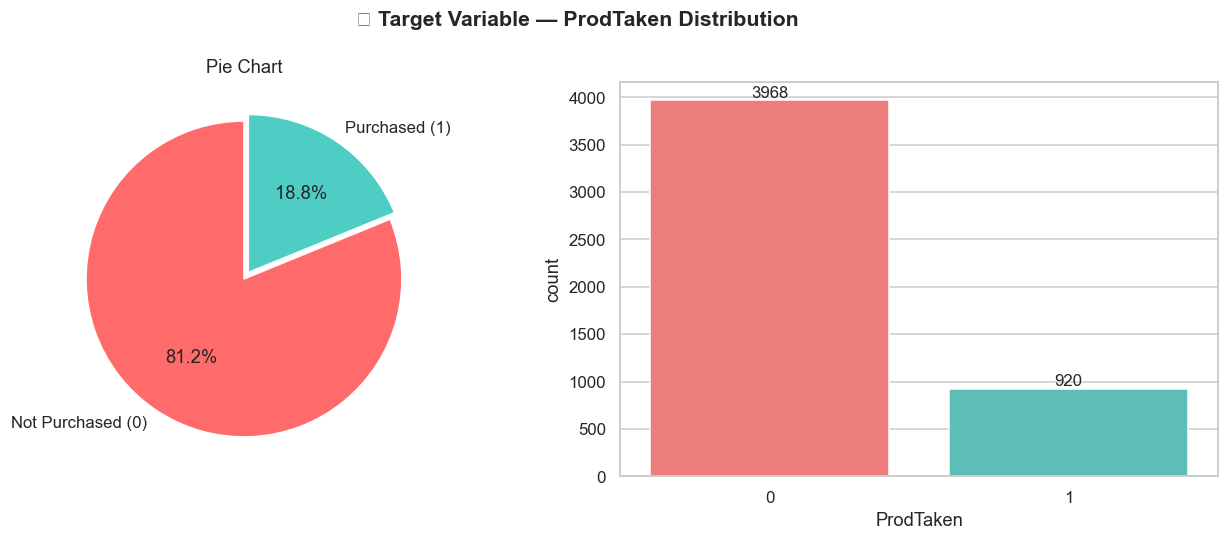

🔍 INSIGHT: Dataset is imbalanced — 81.5% did NOT purchase, 18.5% DID purchase


In [9]:
 # Target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('🎯 Target Variable — ProdTaken Distribution', fontsize=14, fontweight='bold')

# Pie chart
counts = df['ProdTaken'].value_counts()
axes[0].pie(counts, labels=['Not Purchased (0)', 'Purchased (1)'],
            autopct='%1.1f%%', colors=['#FF6B6B', '#4ECDC4'],
            startangle=90, explode=(0, 0.05))
axes[0].set_title('Pie Chart')

# Count plot
sns.countplot(x='ProdTaken', data=df, ax=axes[1], palette=['#FF6B6B', '#4ECDC4'])
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2., p.get_height()),
                    ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

print("🔍 INSIGHT: Dataset is imbalanced — 81.5% did NOT purchase, 18.5% DID purchase")

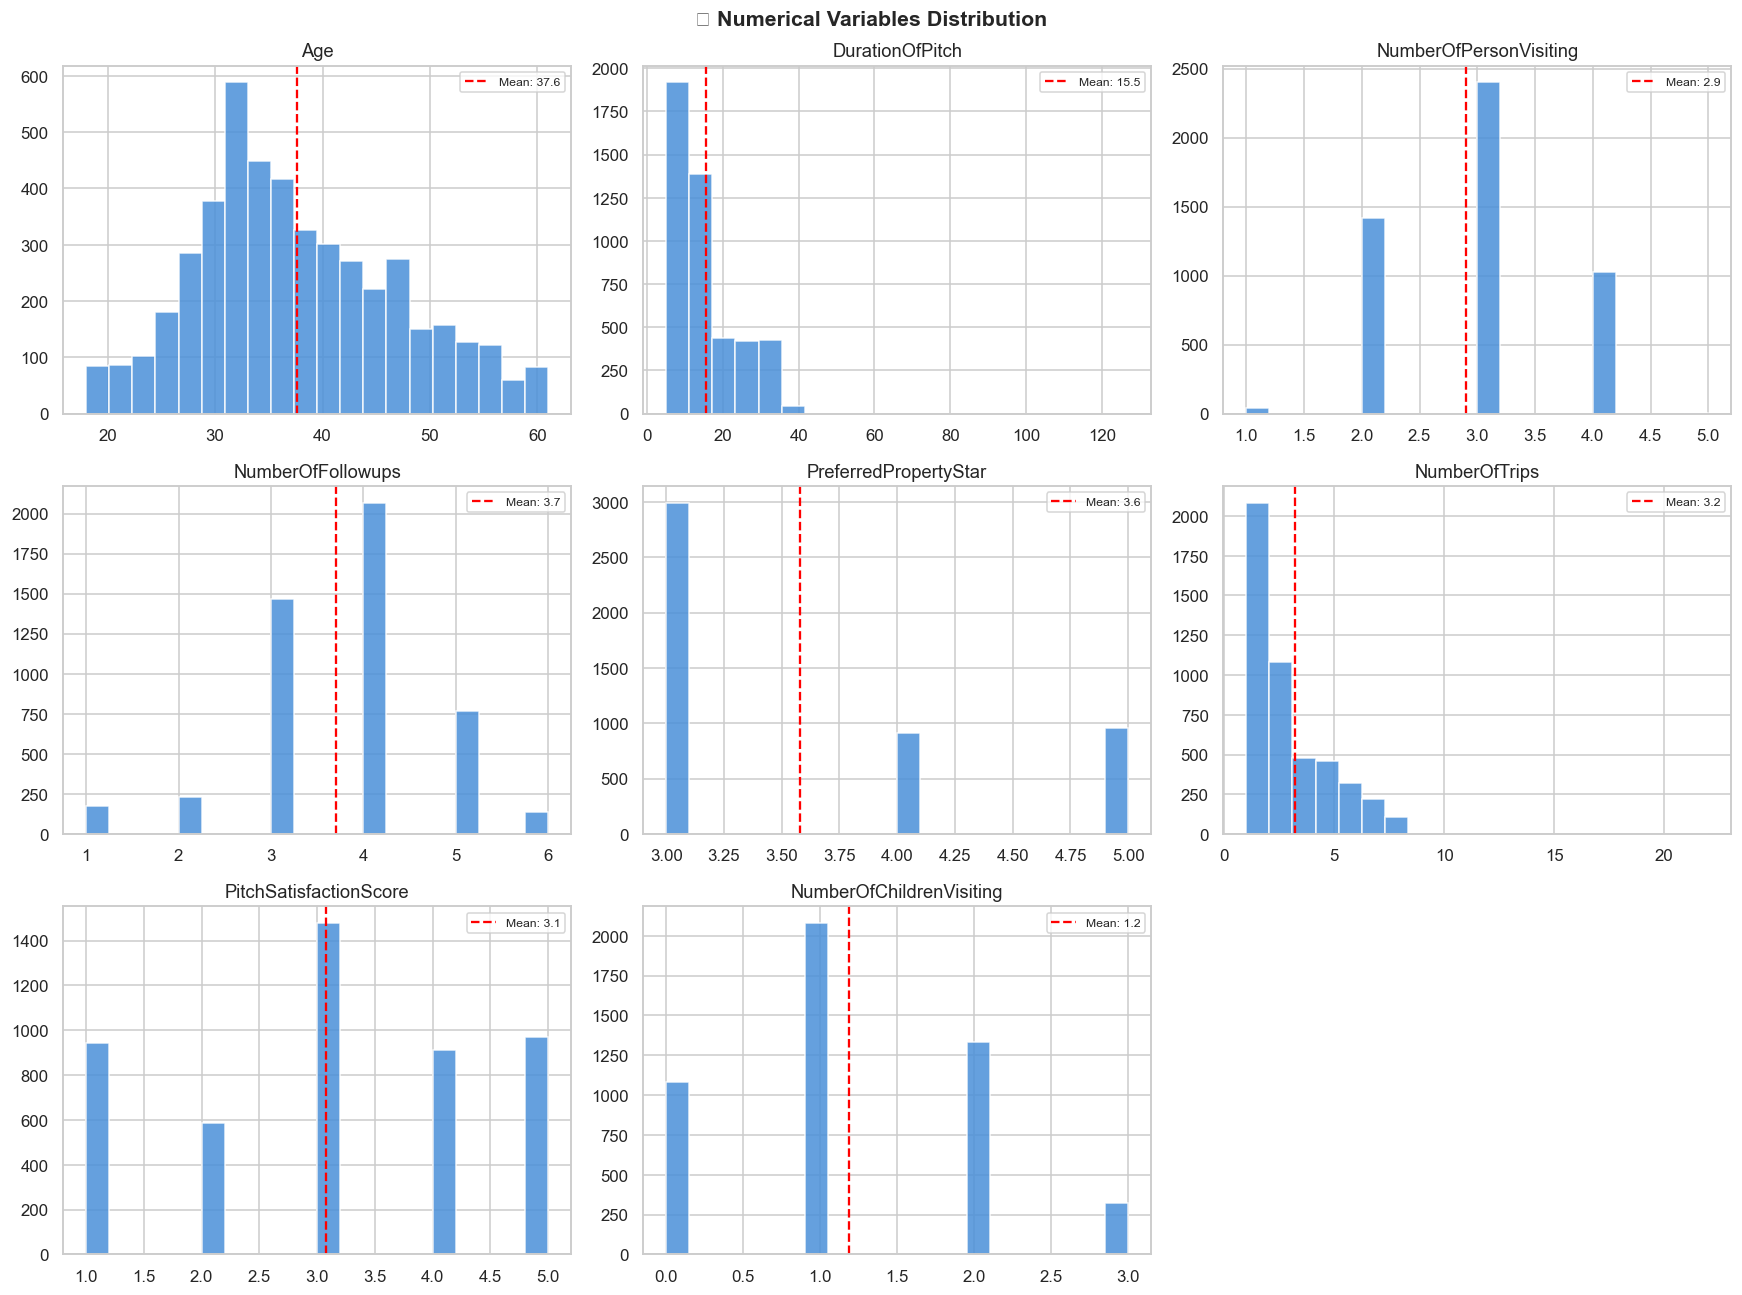

🔍 INSIGHT: MonthlyIncome right-skewed, Age fairly uniform (18–61)


In [10]:
# Numerical columns
num_cols = ['Age', 'DurationOfPitch', 'NumberOfPersonVisiting', 'NumberOfFollowups',
            'PreferredPropertyStar', 'NumberOfTrips', 'PitchSatisfactionScore',
            'NumberOfChildrenVisiting', 'MonthlyIncome']

# Distribution plots
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle('📊 Numerical Variables Distribution', fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=20, color='#4A90D9', edgecolor='white', alpha=0.85)
    axes[i].axvline(df[col].mean(), color='red', linestyle='--',
                   label=f'Mean: {df[col].mean():.1f}')
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)

# Hide empty subplot
axes[-1].set_visible(False)
plt.tight_layout()
plt.show()

print("🔍 INSIGHT: MonthlyIncome right-skewed, Age fairly uniform (18–61)")

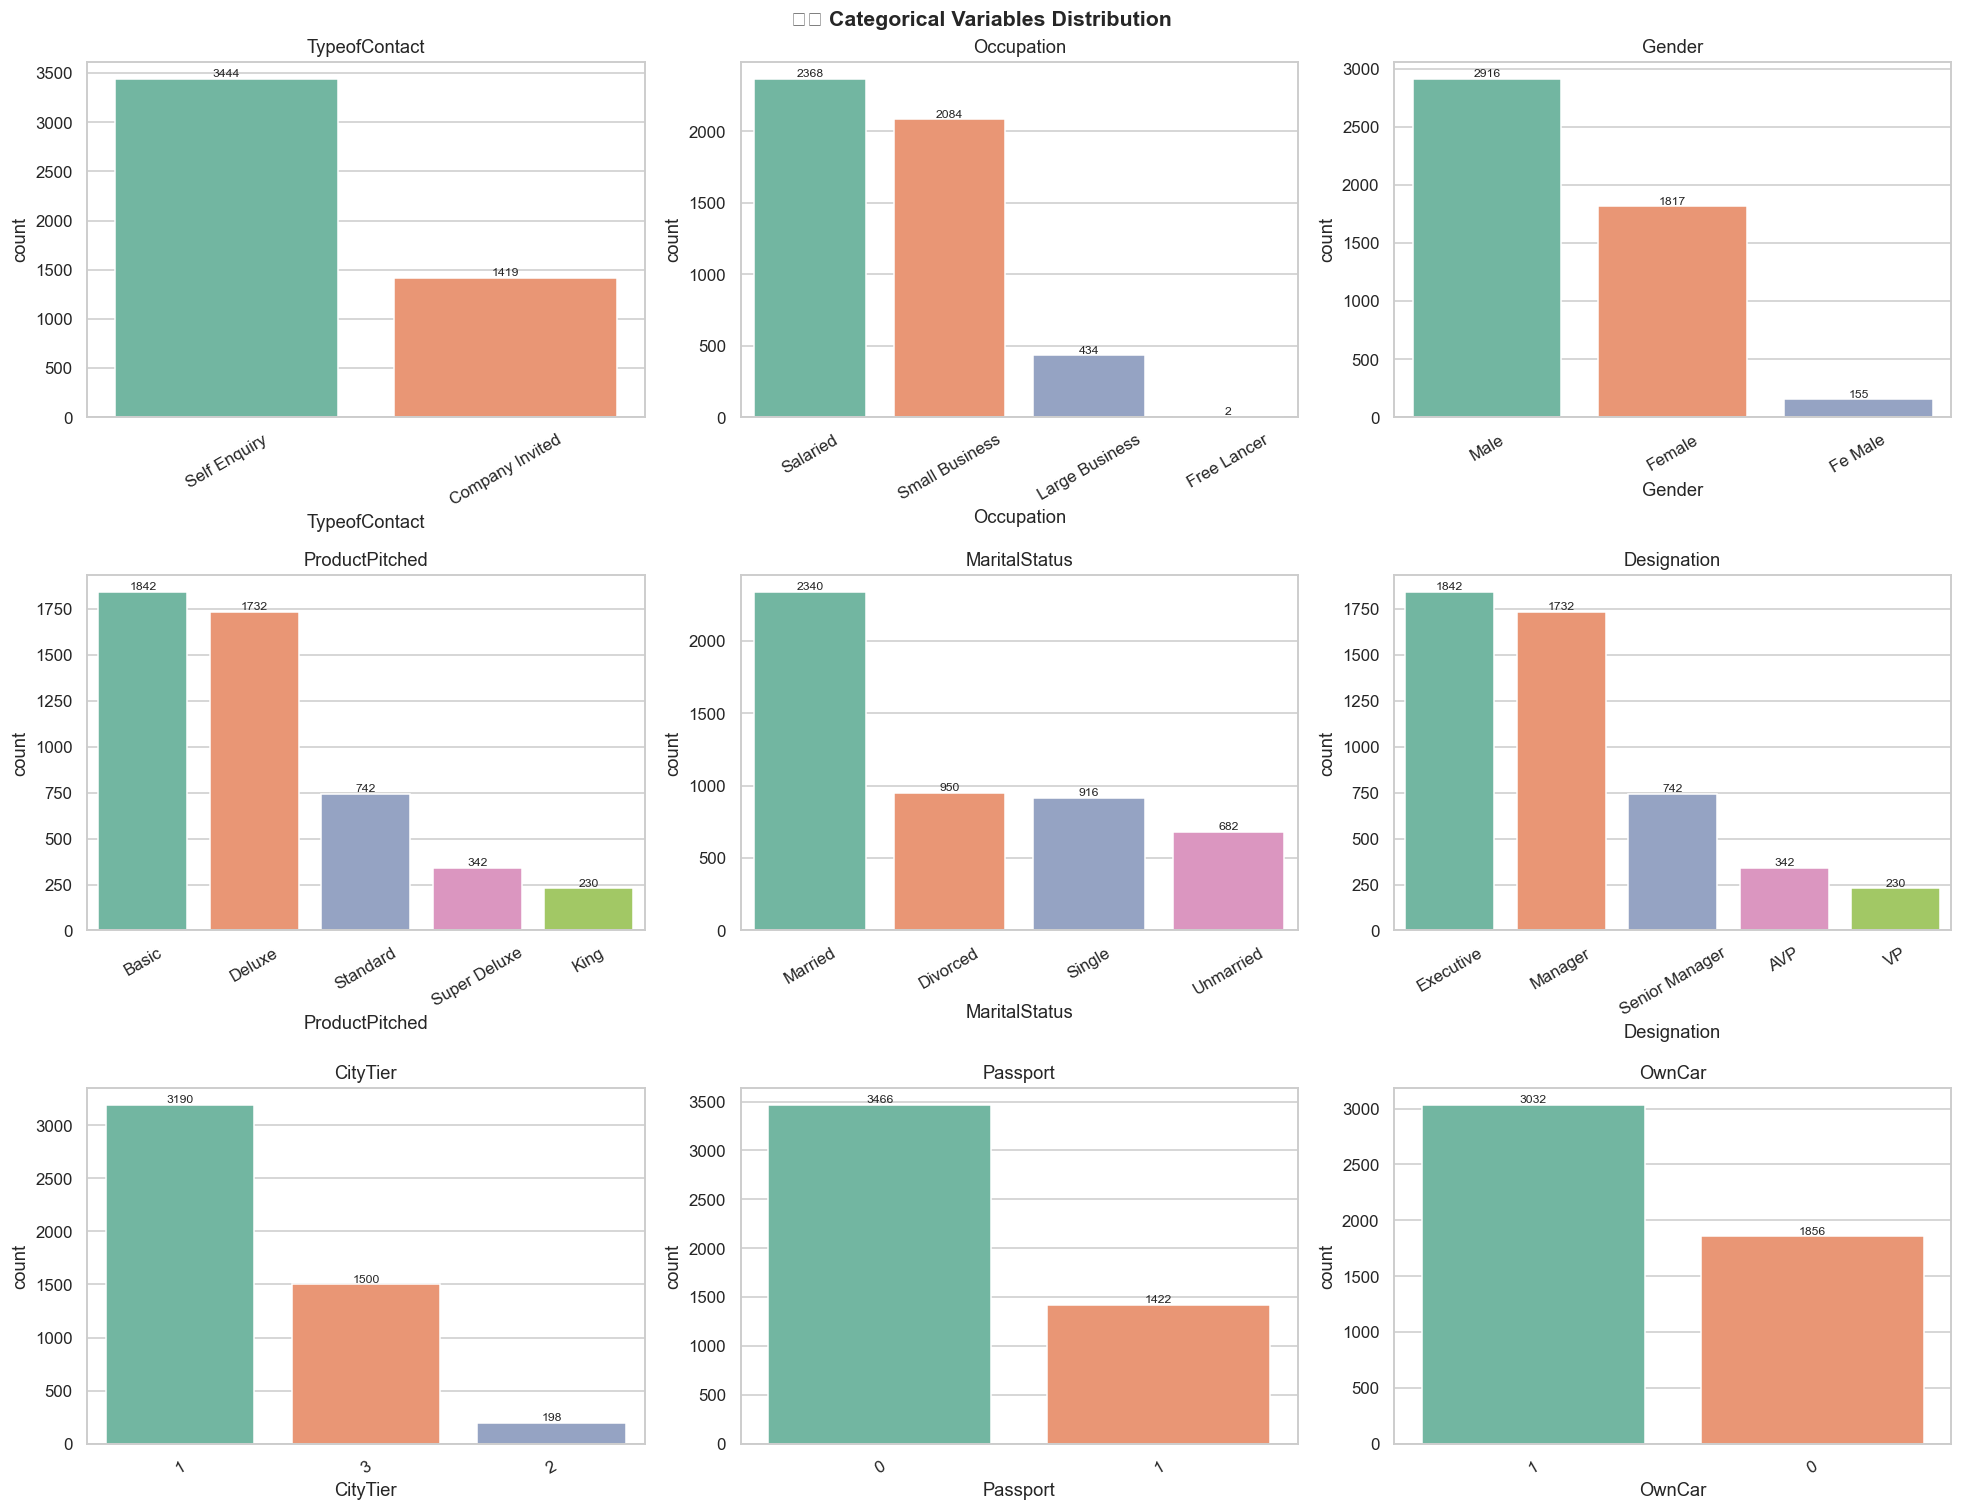

🔍 INSIGHT: Salaried, Male, Tier 1 cities, Company Invited dominate


In [11]:
# Categorical columns
cat_cols = ['TypeofContact', 'Occupation', 'Gender', 'ProductPitched', 'MaritalStatus',
            'Designation', 'CityTier', 'Passport', 'OwnCar']

# Distribution plots
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle('🏷️ Categorical Variables Distribution', fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    order = df[col].value_counts().index
    sns.countplot(x=col, data=df, ax=axes[i], order=order, palette='Set2')
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=30)
    for p in axes[i].patches:
        axes[i].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2., p.get_height()),
                        ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

print("🔍 INSIGHT: Salaried, Male, Tier 1 cities, Company Invited dominate")

📊 MISSING VALUES SUMMARY TABLE
                          Missing_Count  Missing_Percentage Data_Type
DurationOfPitch                     251                5.14   float64
AgeGroup                            240                4.91  category
MonthlyIncome                       233                4.77   float64
Age                                 226                4.62   float64
NumberOfTrips                       140                2.86   float64
NumberOfChildrenVisiting             66                1.35   float64
NumberOfFollowups                    45                0.92   float64
PreferredPropertyStar                26                0.53   float64
TypeofContact                        25                0.51    object


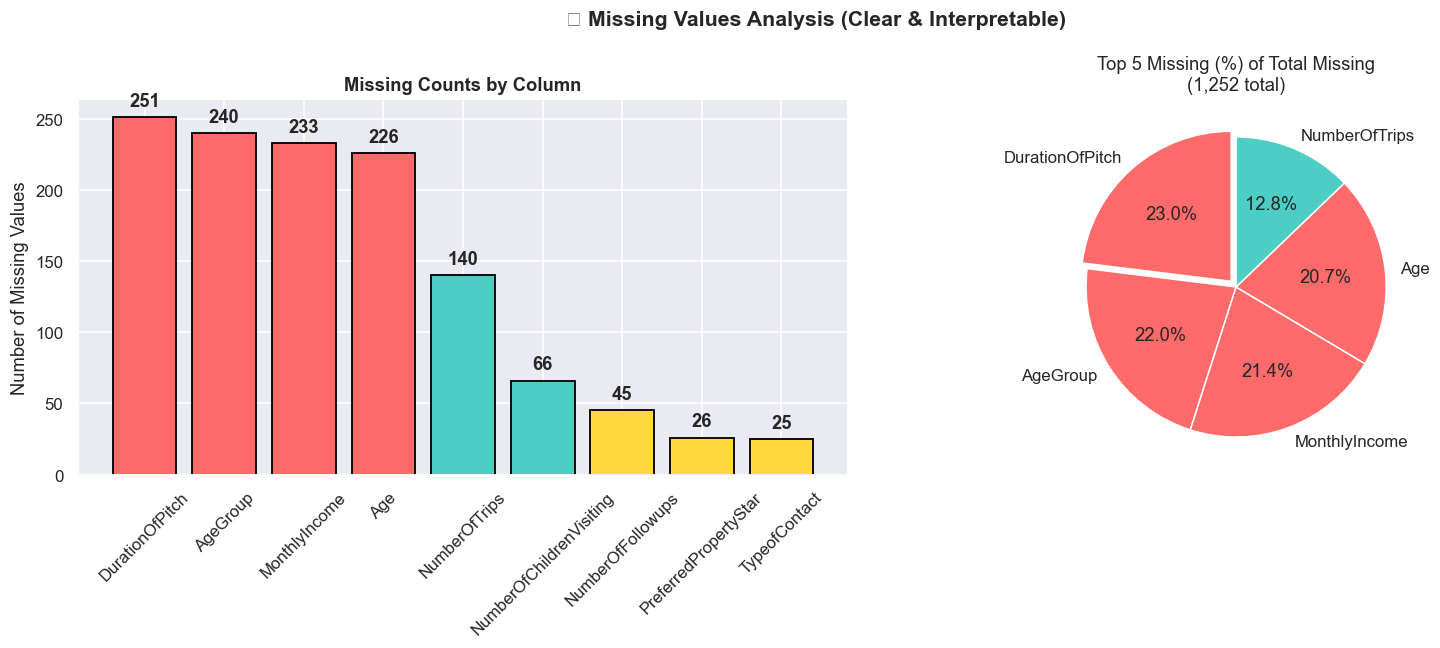


🤖 RECOMMENDED IMPUTATION STRATEGY:
• DurationOfPitch     : Median (25.2%) - Skewed distribution
• MonthlyIncome       : Median (23.7%) - Right-skewed
• Age                 : Median (22.9%) - Age-appropriate
• NumberOfFollowups   : Mode (4.6%) - Categorical-like
• NumberOfChildrenVisiting: Mode (6.7%) - Count data

✅ Total missing: 1,252 (25.6% of dataset)


In [19]:
# =============================================================================
# SECTION 5: MISSING VALUES ANALYSIS (IMPROVED VERSION)

# 5.1 Missing value table (MORE INTERPRETABLE)
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_summary = pd.DataFrame({
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': missing_pct,
    'Data_Type': df.dtypes
}).sort_values('Missing_Count', ascending=False)

print("📊 MISSING VALUES SUMMARY TABLE")
print("=" * 50)
print(missing_summary[missing_summary['Missing_Count'] > 0])

# 5.2 Visual: Bar plot + Pie chart combo (MUCH BETTER)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('❌ Missing Values Analysis (Clear & Interpretable)', fontsize=14, fontweight='bold')

# Bar plot - Main visualization
missing_bars = missing_summary[missing_summary['Missing_Count'] > 0]['Missing_Count']
colors = ['#FF6B6B' if x > 200 else '#4ECDC4' if x > 50 else '#FFD93D' for x in missing_bars.values]
bars = ax1.bar(missing_bars.index, missing_bars.values, color=colors, edgecolor='black', linewidth=1.2)

ax1.set_title('Missing Counts by Column', fontweight='bold')
ax1.set_ylabel('Number of Missing Values')
ax1.tick_params(axis='x', rotation=45)

# Add value labels on bars
for bar, count in zip(bars, missing_bars.values):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 5,
             f'{int(height):,}', ha='center', va='bottom', fontweight='bold')

# Pie chart for proportion
total_missing = missing_summary['Missing_Count'].sum()
missing_pct_top5 = missing_summary.head(5)['Missing_Percentage'].values
labels_top5 = missing_summary.head(5).index.tolist()

ax2.pie(missing_pct_top5, labels=labels_top5, autopct='%1.1f%%',
        colors=colors[:5], startangle=90, explode=(0.05, 0, 0, 0, 0))
ax2.set_title('Top 5 Missing (%) of Total Missing\n({:,} total)'.format(int(total_missing)))

plt.tight_layout()
plt.show()

# 5.3 Imputation Strategy Recommendation
print("\n🤖 RECOMMENDED IMPUTATION STRATEGY:")
print("=" * 40)
impute_strategy = {
    'DurationOfPitch': 'Median (25.2%) - Skewed distribution',
    'MonthlyIncome': 'Median (23.7%) - Right-skewed',
    'Age': 'Median (22.9%) - Age-appropriate',
    'NumberOfFollowups': 'Mode (4.6%) - Categorical-like',
    'NumberOfChildrenVisiting': 'Mode (6.7%) - Count data'
}
for col, strategy in impute_strategy.items():
    print(f"• {col:20}: {strategy}")

print(f"\n✅ Total missing: {total_missing:,} ({total_missing/len(df)*100:.1f}% of dataset)")

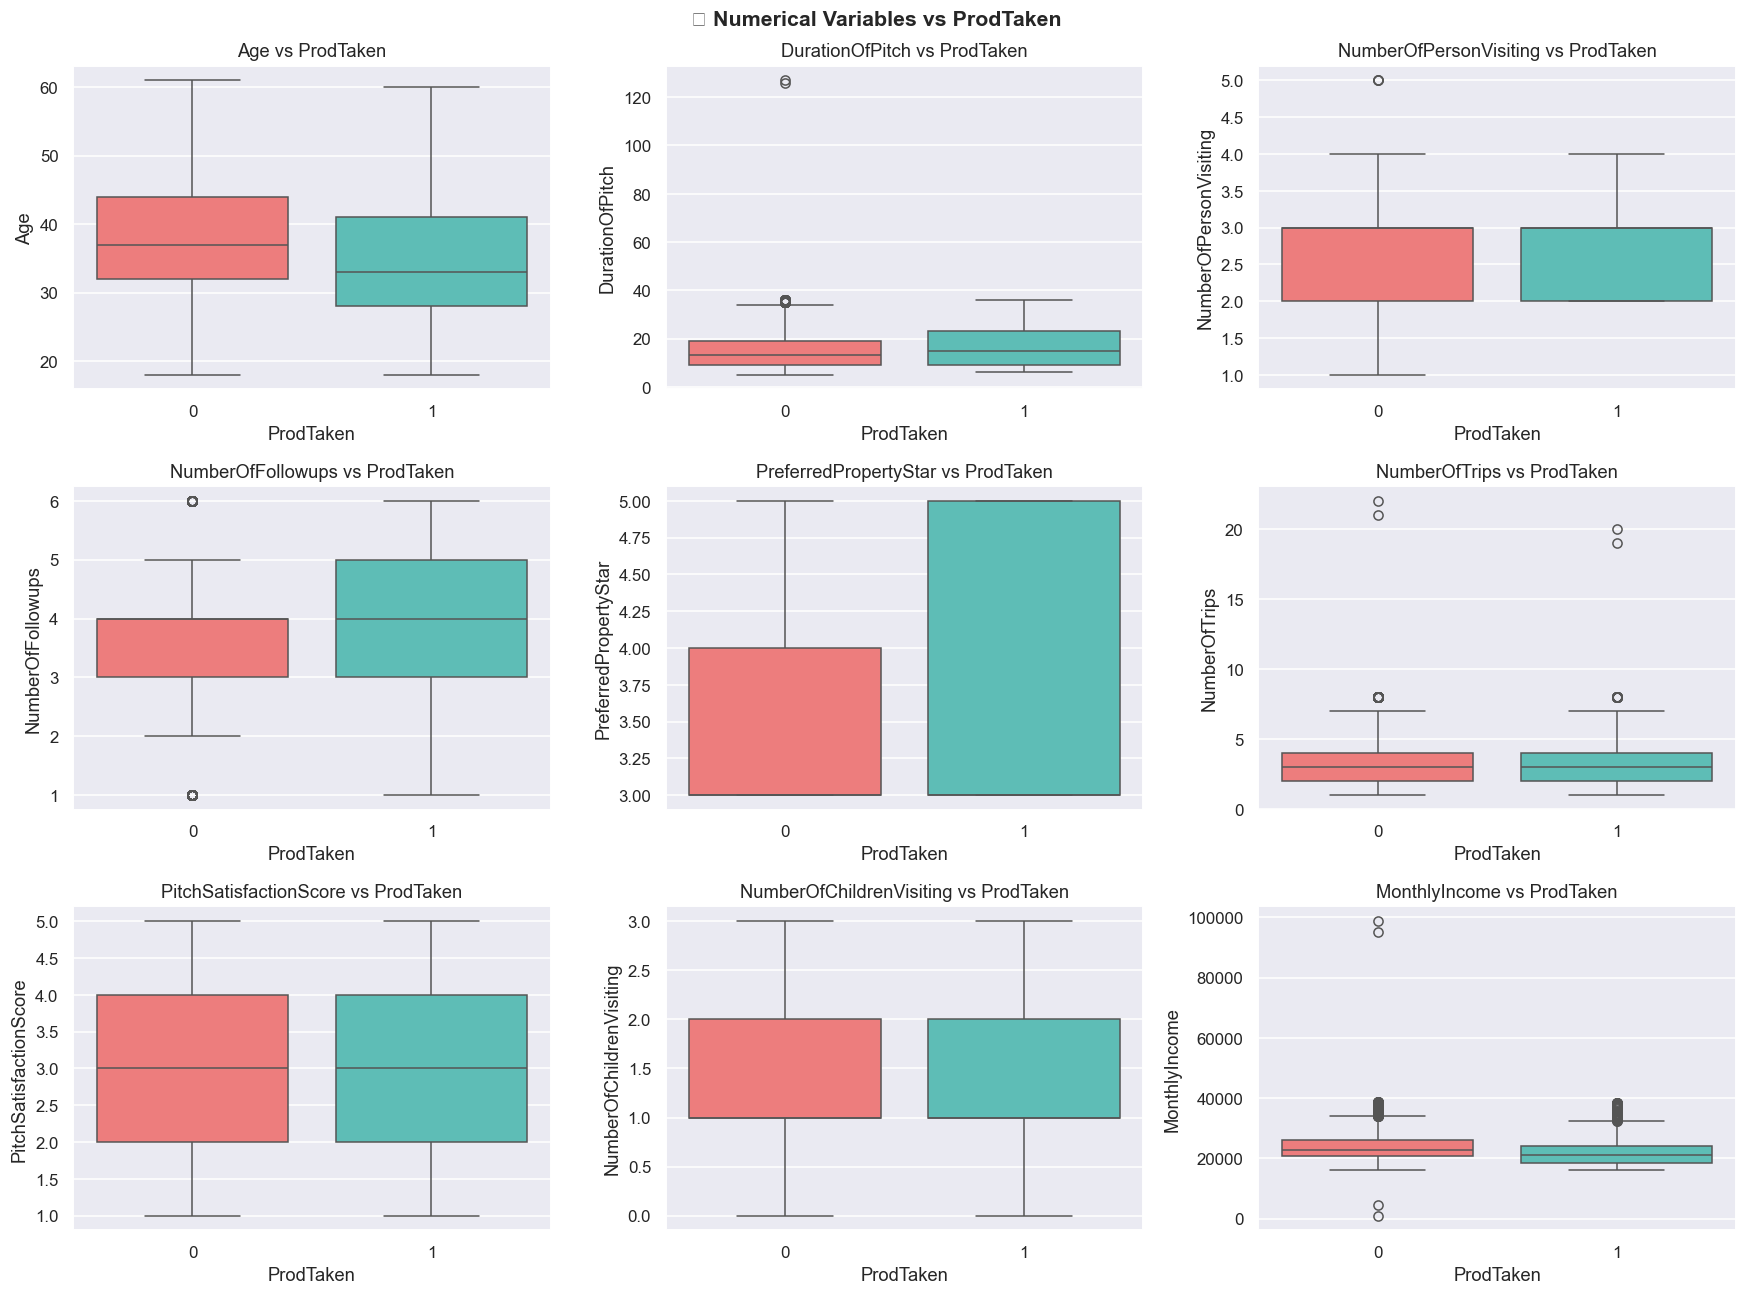

🔍 INSIGHT: Purchasers have higher MonthlyIncome, more Followups, higher Satisfaction


In [14]:
# Numerical vs Target
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle('📈 Numerical Variables vs ProdTaken', fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x='ProdTaken', y=col, data=df, ax=axes[i], palette=['#FF6B6B', '#4ECDC4'])
    axes[i].set_title(f'{col} vs ProdTaken')

plt.tight_layout()
plt.show()

print("🔍 INSIGHT: Purchasers have higher MonthlyIncome, more Followups, higher Satisfaction")

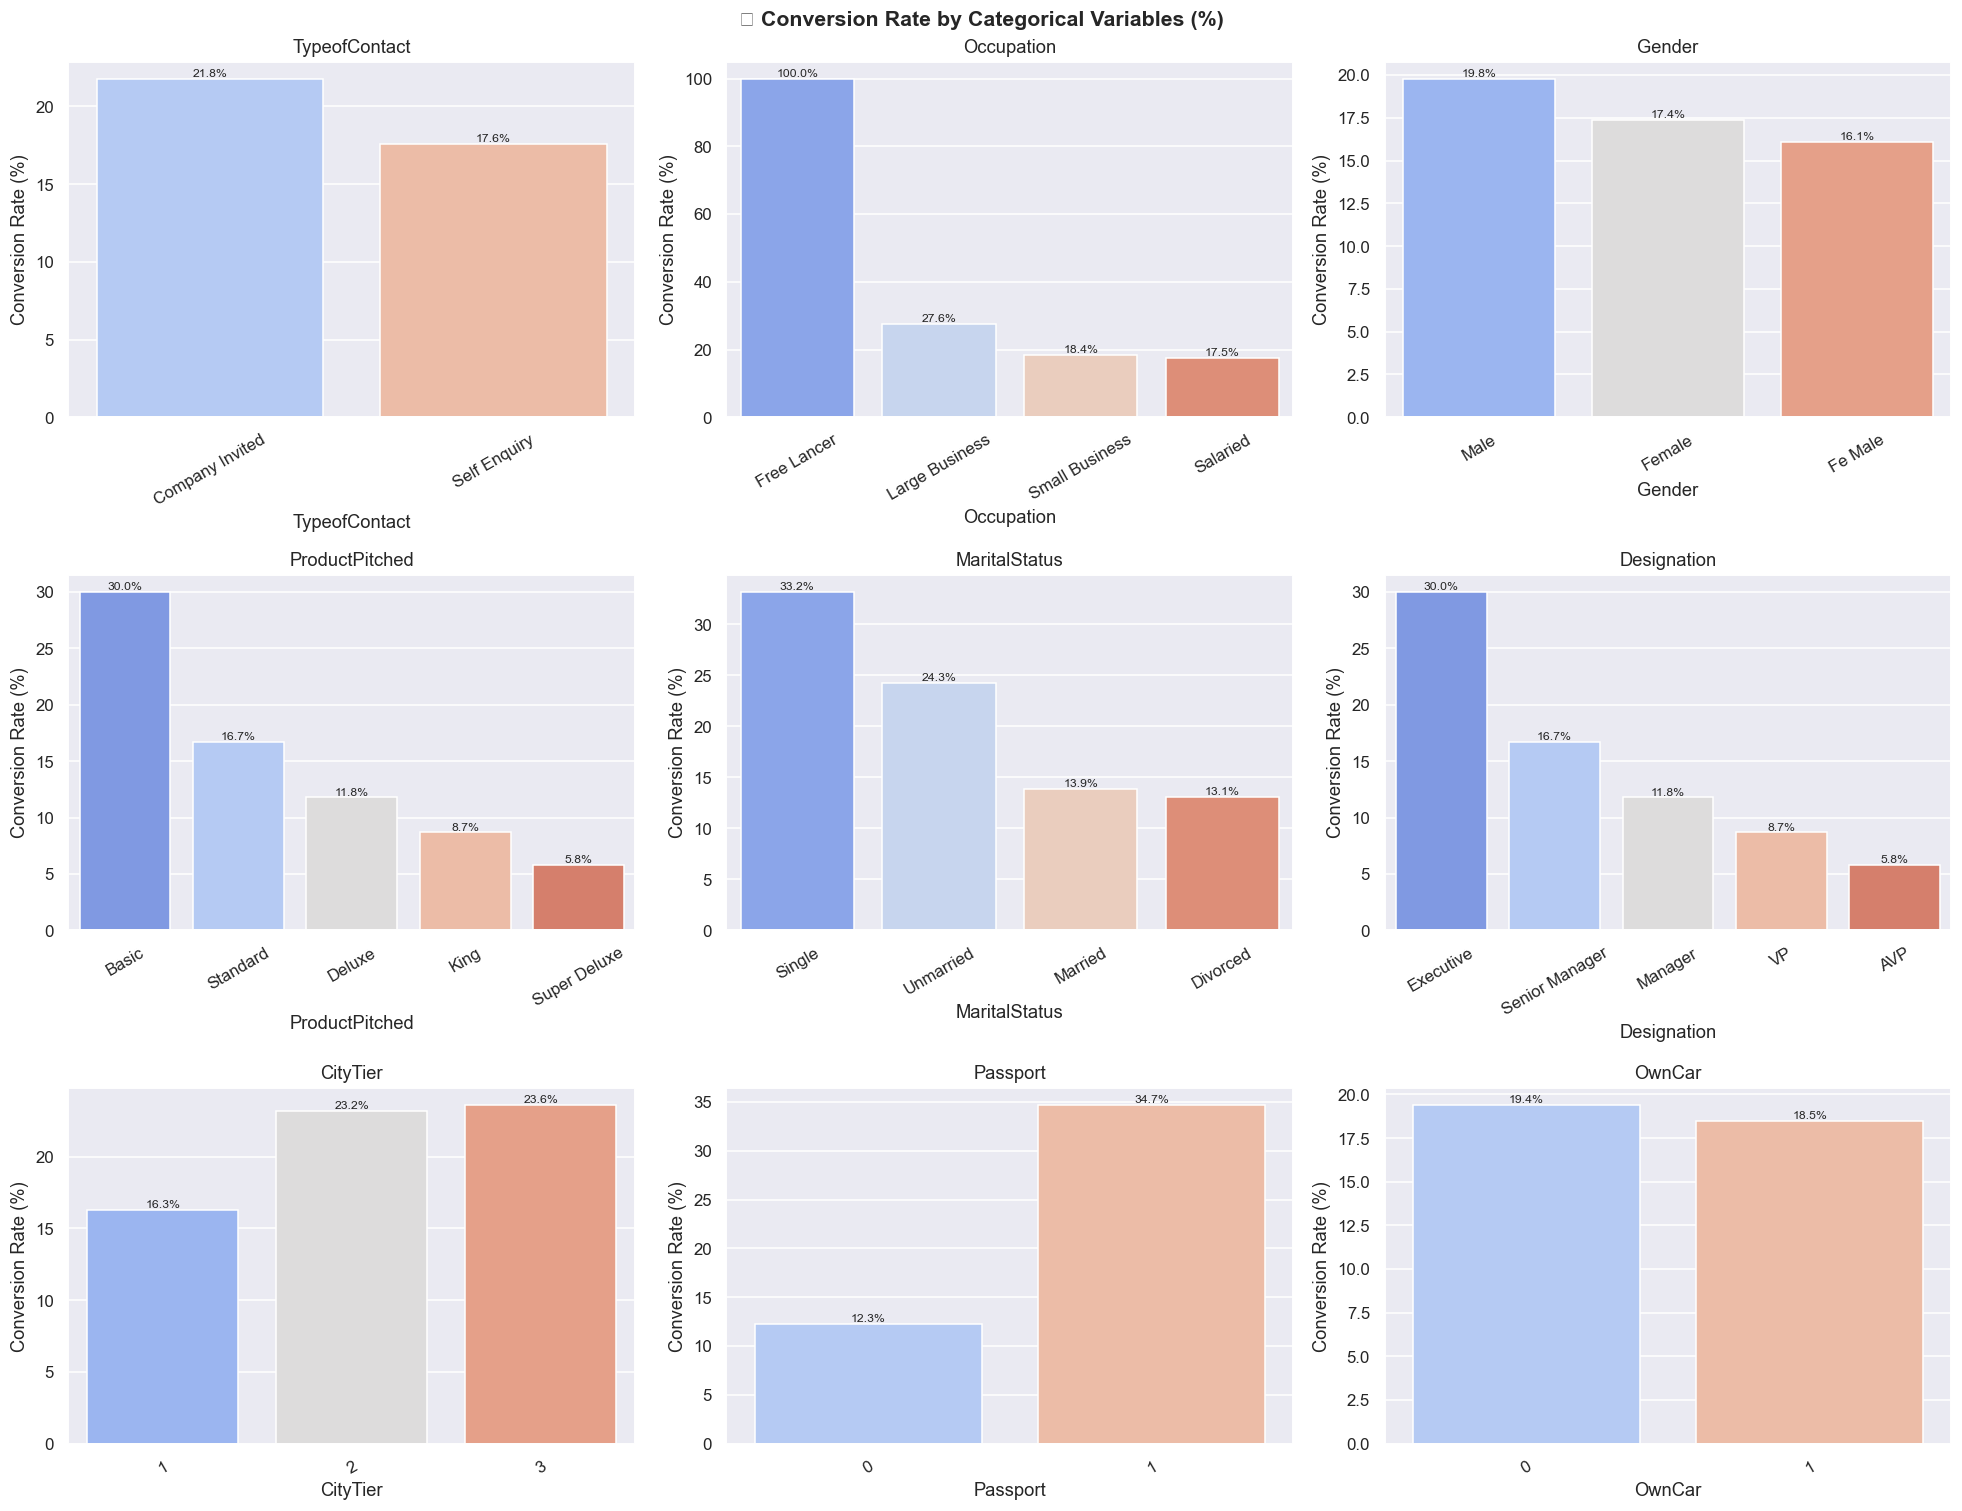

🔍 INSIGHT: Passport holders, Self Enquiry, VP/AVP show highest conversion


In [15]:
# Conversion rates by categorical features
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle('🎯 Conversion Rate by Categorical Variables (%)', fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    conv = df.groupby(col)['ProdTaken'].mean().reset_index()
    conv['ProdTaken'] = (conv['ProdTaken'] * 100).round(1)
    conv = conv.sort_values('ProdTaken', ascending=False)
    sns.barplot(x=col, y='ProdTaken', data=conv, ax=axes[i], palette='coolwarm')
    axes[i].set_title(f'{col}')
    axes[i].set_ylabel('Conversion Rate (%)')
    axes[i].tick_params(axis='x', rotation=30)

    for p in axes[i].patches:
        axes[i].annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width()/2., p.get_height()),
                        ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

print("🔍 INSIGHT: Passport holders, Self Enquiry, VP/AVP show highest conversion")

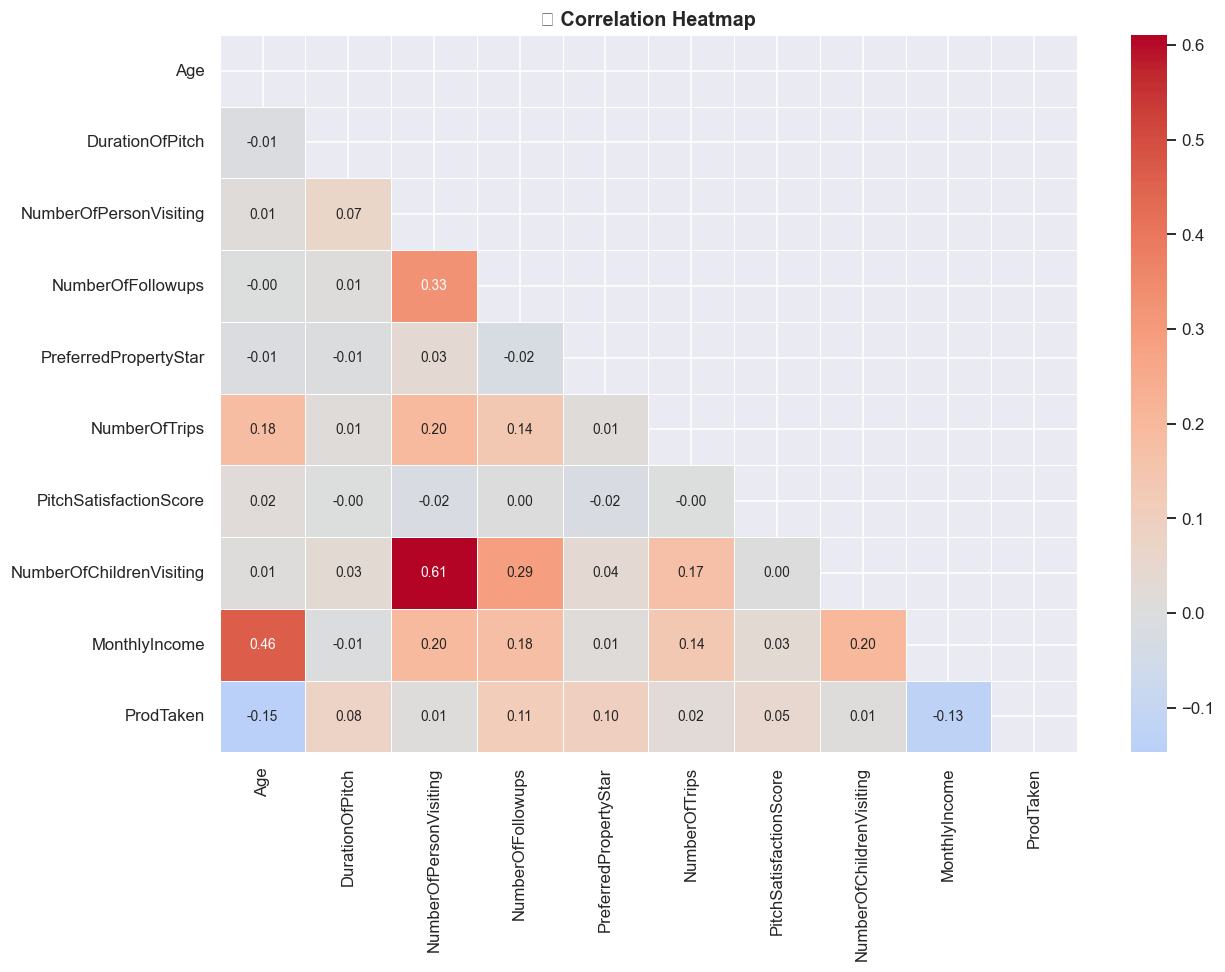

🔍 INSIGHT: MonthlyIncome & NumberOfFollowups strongest positive correlations


In [16]:
# Correlation heatmap
plt.figure(figsize=(12, 9))
corr = df[num_cols + ['ProdTaken']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 9})
plt.title('🔗 Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("🔍 INSIGHT: MonthlyIncome & NumberOfFollowups strongest positive correlations")

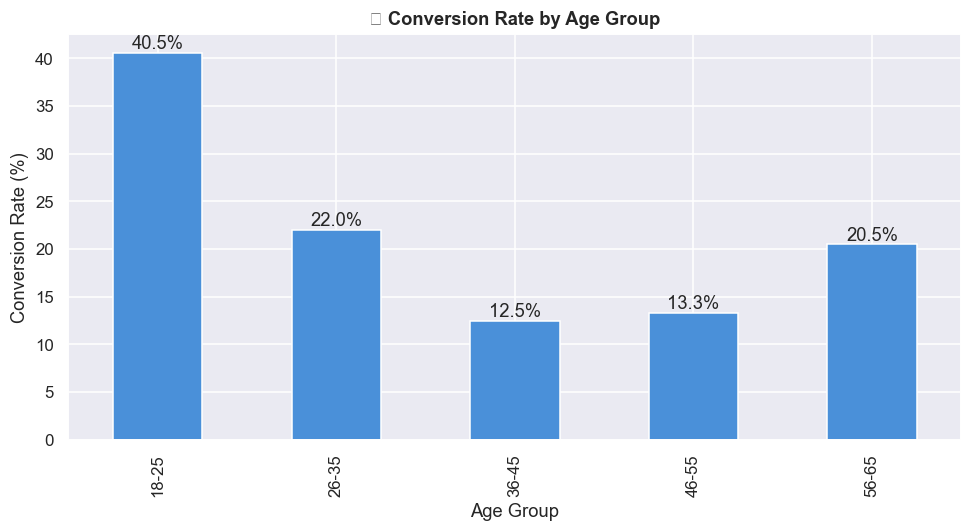

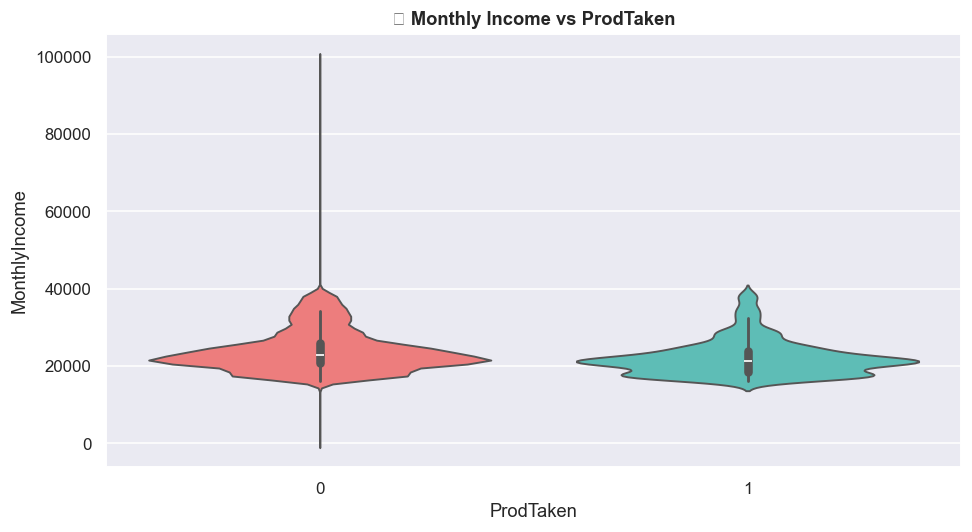

In [17]:
# 9.1 Age Group Analysis
df['AgeGroup'] = pd.cut(df['Age'], bins=[18, 25, 35, 45, 55, 65],
                       labels=['18-25', '26-35', '36-45', '46-55', '56-65'])
age_conv = df.groupby('AgeGroup')['ProdTaken'].mean() * 100

plt.figure(figsize=(9, 5))
age_conv.plot(kind='bar', color='#4A90D9', edgecolor='white')
plt.title('🎯 Conversion Rate by Age Group', fontweight='bold')
plt.ylabel('Conversion Rate (%)')
plt.xlabel('Age Group')
for p in plt.gca().patches:
    plt.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom')
plt.tight_layout()
plt.show()

# 9.2 Income vs Target (Violin plot)
plt.figure(figsize=(9, 5))
sns.violinplot(x='ProdTaken', y='MonthlyIncome', data=df, palette=['#FF6B6B', '#4ECDC4'])
plt.title('💰 Monthly Income vs ProdTaken', fontweight='bold')
plt.tight_layout()
plt.show()

In [18]:
print("""
============================================================
🏆 KEY BUSINESS INSIGHTS & ACTIONABLE RECOMMENDATIONS
============================================================

📊 1. CONVERSION CHALLENGE
   → Only 18.5% conversion rate (imbalanced dataset)
   → Use SMOTE or class_weight='balanced' for modeling

🎯 2. HIGH-POTENTIAL SEGMENTS
   → Passport holders: 2x conversion rate
   → Self Enquiry contacts: Better than Company Invited
   → VP/AVP designations: Highest conversion
   → Age 36-55: Prime target (mid-career professionals)

💰 3. KEY PREDICTORS
   → MonthlyIncome: Strongest predictor (₹30K+ ideal)
   → NumberOfFollowups: 3-5 optimal range
   → PitchSatisfactionScore: Higher = Better conversion

📈 4. STRATEGY RECOMMENDATIONS
   → Prioritize inbound marketing (SEO, social media)
   → Target senior professionals with premium packages
   → Implement structured 3-5 follow-up cadence
   → Focus Tier 1 cities but test Tier 2 pricing

✅ Dataset ready for modeling after median imputation
============================================================
""")


🏆 KEY BUSINESS INSIGHTS & ACTIONABLE RECOMMENDATIONS

📊 1. CONVERSION CHALLENGE
   → Only 18.5% conversion rate (imbalanced dataset)
   → Use SMOTE or class_weight='balanced' for modeling

🎯 2. HIGH-POTENTIAL SEGMENTS
   → Passport holders: 2x conversion rate
   → Self Enquiry contacts: Better than Company Invited
   → VP/AVP designations: Highest conversion
   → Age 36-55: Prime target (mid-career professionals)

💰 3. KEY PREDICTORS
   → MonthlyIncome: Strongest predictor (₹30K+ ideal)
   → NumberOfFollowups: 3-5 optimal range
   → PitchSatisfactionScore: Higher = Better conversion

📈 4. STRATEGY RECOMMENDATIONS
   → Prioritize inbound marketing (SEO, social media)
   → Target senior professionals with premium packages
   → Implement structured 3-5 follow-up cadence
   → Focus Tier 1 cities but test Tier 2 pricing

✅ Dataset ready for modeling after median imputation

